# Optimal skills to learn for Data roles?

## Steps:

1. Group skills to determine median salry and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. What technologies are more prevalent?

In [1]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from adjustText import adjust_text
from datasets import load_dataset

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA = df[(df['job_country'].isin(['United States', 'Mexico', 'Germany', 'UK'])) & (df['job_title_short'] == 'Data Analyst')].dropna(subset='salary_year_avg').copy()

In [3]:
df_DA_exploded = df_DA.explode('job_skills')
df_DA_exploded[['salary_year_avg', 'job_skills']].head(5) 

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [27]:
df_skills = df_DA_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_skills = df_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
job_count = len(df_DA)
df_skills['skill_percent'] =  df_skills['skill_count'] / job_count * 100
skill_percent = 5
df_high_demand = df_skills[df_skills['skill_percent'] > skill_percent]
df_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2543,92238.50,57.339346
excel,1831,84500.00,41.285231
python,1457,97500.00,32.852311
tableau,1390,92875.00,31.341601
sas,928,90000.00,20.924464
r,904,92500.00,20.383315
power bi,854,90000.00,19.255919
powerpoint,464,85000.00,10.462232
word,461,81194.75,10.394589


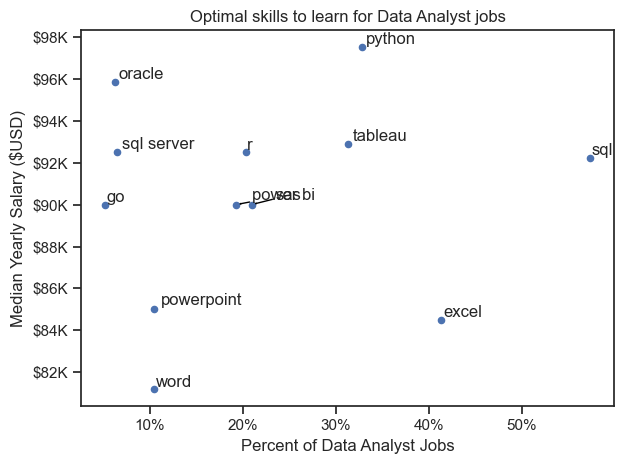

In [29]:

df_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

#Text for adjustText
texts = []
for i, txt in enumerate(df_high_demand.index):
    texts.append(plt.text(df_high_demand['skill_percent'].iloc[i], df_high_demand['median_salary'].iloc[i], txt))

#Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

#Title, xlabel and ylabel
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Optimal skills to learn for Data Analyst jobs')

#Chart formatting
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%')) #xaxis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')) #yaxis

#Adjust layout
plt.tight_layout()
plt.show()

In [30]:
df_tech = df['job_type_skills'].copy()

#removes duplicates
df_tech = df_tech.drop_duplicates()

#remove Nan values
df_tech = df_tech.dropna()

#combine all dictionaries into one
tech_dict = {}
for row in df_tech:
    row_dict = ast.literal_eval(row)                                    #converting string to dictionary
    for key, value in row_dict.items():
        if key in tech_dict:
            tech_dict[key] += value                                     #if key already exist, just add value
        else:
            tech_dict[key] = value                                      #if key doesnt exist, then add value and key

#remove duplicates by converting values and then back to a list
for key, value in tech_dict.items():
    tech_dict[key] = list(set(value))

#tech_dict

In [31]:
df_tech = pd.DataFrame(list(tech_dict.items()), columns=['technology', 'skills'])
df_tech = df_tech.explode('skills')
df_tech

,technology,skills
0,analyst_tools,powerpoint
0,analyst_tools,powerbi
0,analyst_tools,datarobot
0,analyst_tools,spss
0,analyst_tools,sas
...,...,...
9,sync,unify
9,sync,wire
9,sync,twilio
9,sync,mattermost


In [32]:
df_plot = df_high_demand.merge(df_tech, left_on='job_skills', right_on='skills')

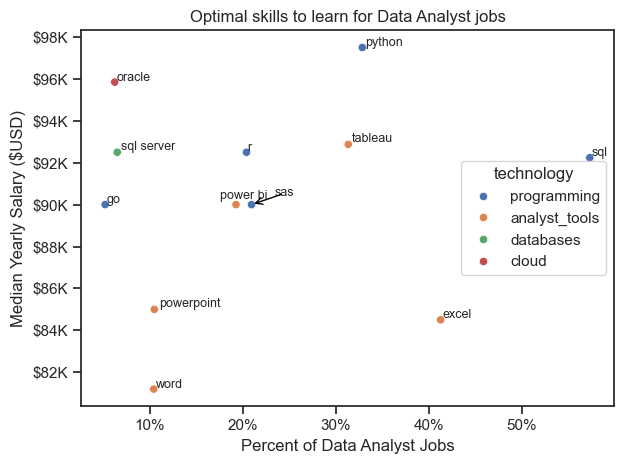

In [42]:
#df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')
#Seaborn
sns.despine()
sns.set_theme(style='ticks')
sns.scatterplot(data=df_plot, x='skill_percent', y='median_salary', hue='technology')

#Text for adjustText
texts = []
for i, txt in enumerate(df_high_demand.index):
    texts.append(plt.text(df_high_demand['skill_percent'].iloc[i], df_high_demand['median_salary'].iloc[i], txt, fontsize=9))

#Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'), force_text=3, 
                force_points=2, expand_points=(1.5, 1.5),
                expand_text=(1.5, 1.5), lim=200, only_move={'points':'y', 'text':'xy'}
            )

#Title, xlabel and ylabel
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Optimal skills to learn for Data Analyst jobs')

#Chart formatting
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%')) #xaxis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')) #yaxis

#Adjust layout
plt.tight_layout()
plt.show()